In [18]:
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from collections import Counter

# Modelos y métricas
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.pipeline import Pipeline

# --- NUEVOS CLASIFICADORES ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [19]:
# Celda 1: Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

In [20]:
# Codificar etiquetas a números para evitar errores en MLPClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Etiquetas originales:", classes)
print("Etiquetas codificadas:", np.unique(y_encoded))


Etiquetas originales: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']
Etiquetas codificadas: [0 1 2 3 4 5]


In [21]:
# Celda 2: Carga, normalización y división de datos
# Cambia la ruta por la carpeta donde tengas las imágenes
X, y, classes = load_image_dataset("CMS_data", size=(64,64))
print("Datos cargados.")
print(f"Clases: {classes}")

# Normalizar al rango [0,1]
X = X / X.max()

# Aplanar imágenes para modelos clásicos
X_flat = X.reshape(len(X), -1)

# División train/test USANDO LAS ETIQUETAS CODIFICADAS
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, 
    y_encoded,          # <--- CORRECCIÓN
    test_size=0.2,
    stratify=y_encoded, # <--- TAMBIÉN AQUÍ
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Datos cargados.
Clases: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']
Train: (48000, 4096), Test: (12000, 4096)


In [22]:
# Binarizar las etiquetas (necesario para ROC multiclase)
# Usamos las clases codificadas correctamente
classes_num = np.arange(len(le.classes_))

y_test_bin = label_binarize(y_test, classes=classes_num)

n_classes = y_test_bin.shape[1]
print(f"Número de clases binarizadas: {n_classes}")
print("Clases codificadas:", le.classes_)


Número de clases binarizadas: 6
Clases codificadas: ['electron' 'muon' 'neutrino' 'proton' 'quark' 'tau']


In [23]:
# --- Función para graficar ROC (basada en tu referencia) ---
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# --- Función para graficar Curvas de Aprendizaje ---
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Accuracy)")
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy"
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r",
             label="Score de Entrenamiento (Train)")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g",
             label="Score de Validación (Test/CV)")
    
    plt.legend(loc="best")
    plt.show()

In [24]:
print("Iniciando GridSearch para ANN (MLPClassifier)... (Esto puede tardar)")

# NOTA: Las Redes Neuronales son muy sensibles al escalado de datos.
# Aunque nuestros datos de píxeles ya están en [0, 1], usaremos StandardScaler
# ya que es una práctica estándar para ANN.
pipeline_ann = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, n_iter_no_change=10))
])

# Parámetros para el MLP (Red Neuronal)
param_grid_ann = {
    # Probamos una capa oculta de 50 neuronas y una de 100
    'mlp__hidden_layer_sizes': [(50,), (100,)], 
    'mlp__alpha': [0.0001, 0.001] # Regularización L2
}

# n_jobs=-1 usa todos los procesadores. cv=2 para hacerlo más rápido.
grid_ann = GridSearchCV(pipeline_ann, param_grid_ann, cv=2, scoring='accuracy', n_jobs=-1, verbose=2)
grid_ann.fit(X_train, y_train)

# Obtenemos el mejor pipeline (que incluye el scaler y el modelo)
best_ann = grid_ann.best_estimator_
print(f"Mejores parámetros para ANN: {grid_ann.best_params_}")

Iniciando GridSearch para ANN (MLPClassifier)... (Esto puede tardar)
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Mejores parámetros para ANN: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (100,)}


In [25]:
print("--- Reporte de Clasificación (ANN) ---")
# El 'best_ann' es un pipeline, predecirá automáticamente escalando los datos
y_pred_ann = best_ann.predict(X_test)
print(classification_report(y_test, y_pred_ann, target_names=classes))

--- Reporte de Clasificación (ANN) ---
              precision    recall  f1-score   support

    electron       0.53      0.54      0.54      2000
        muon       0.57      0.46      0.51      2000
    neutrino       0.86      0.87      0.86      2000
      proton       1.00      1.00      1.00      2000
       quark       0.99      0.98      0.99      2000
         tau       0.70      0.83      0.76      2000

    accuracy                           0.78     12000
   macro avg       0.78      0.78      0.78     12000
weighted avg       0.78      0.78      0.78     12000



--- Matriz de Confusión (ANN) ---


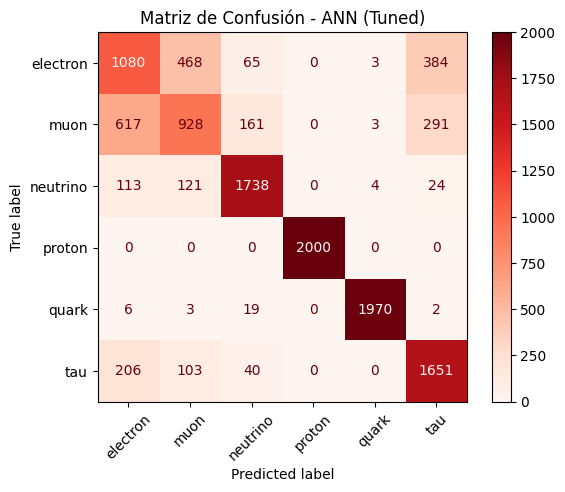

In [26]:
print("--- Matriz de Confusión (ANN) ---")
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=classes)
disp_ann.plot(cmap="Reds", xticks_rotation=45)
plt.title("Matriz de Confusión - ANN (Tuned)")
plt.show()

--- Precisión por Clase (ANN) ---


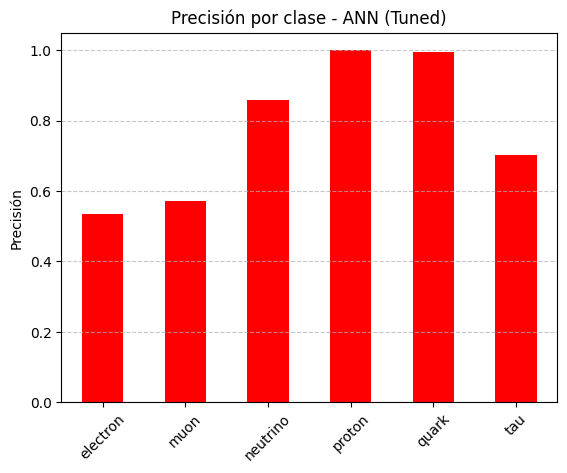

In [27]:
print("--- Precisión por Clase (ANN) ---")
report_ann_dict = classification_report(y_test, y_pred_ann, output_dict=True, target_names=classes)
df_ann = pd.DataFrame(report_ann_dict).transpose()

df_ann.loc[classes, "precision"].plot(kind="bar", color="red")
plt.title("Precisión por clase - ANN (Tuned)")
plt.ylabel("Precisión")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- Curvas ROC (ANN) ---


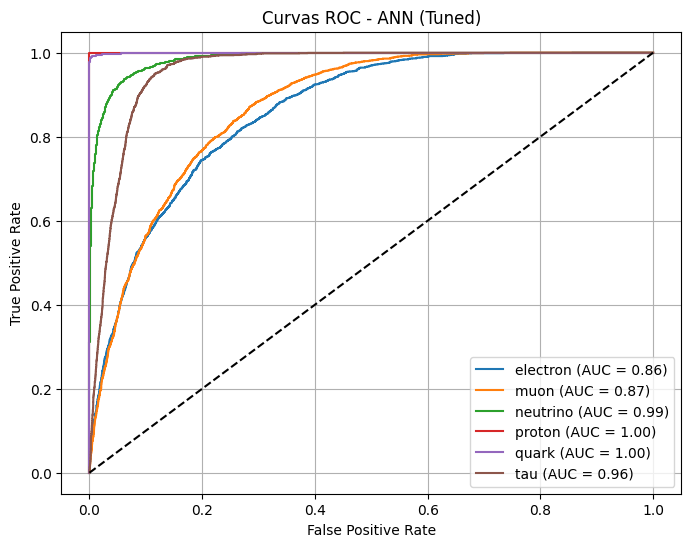

In [28]:
print("--- Curvas ROC (ANN) ---")
y_score_ann = best_ann.predict_proba(X_test)
plot_multiclass_roc(y_test_bin, y_score_ann, classes, "Curvas ROC - ANN (Tuned)")

--- Curva de Aprendizaje (ANN) ---


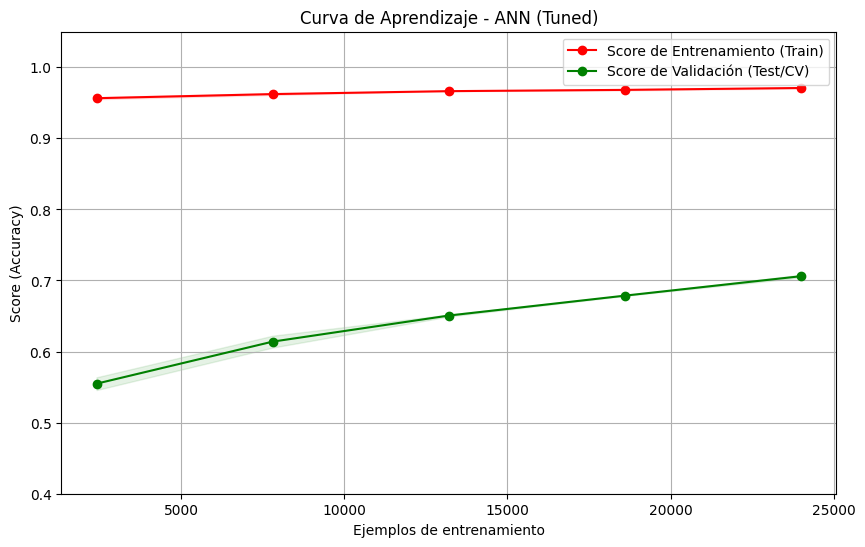

In [29]:
print("--- Curva de Aprendizaje (ANN) ---")
# Nota: Pasamos el pipeline completo 'best_ann' a la función
plot_learning_curve(best_ann, "Curva de Aprendizaje - ANN (Tuned)", X_train, y_train, cv=2, ylim=(0.4, 1.05))